In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize pixel values to [0, 1]

print("Dataset Loaded Successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset Loaded Successfully.


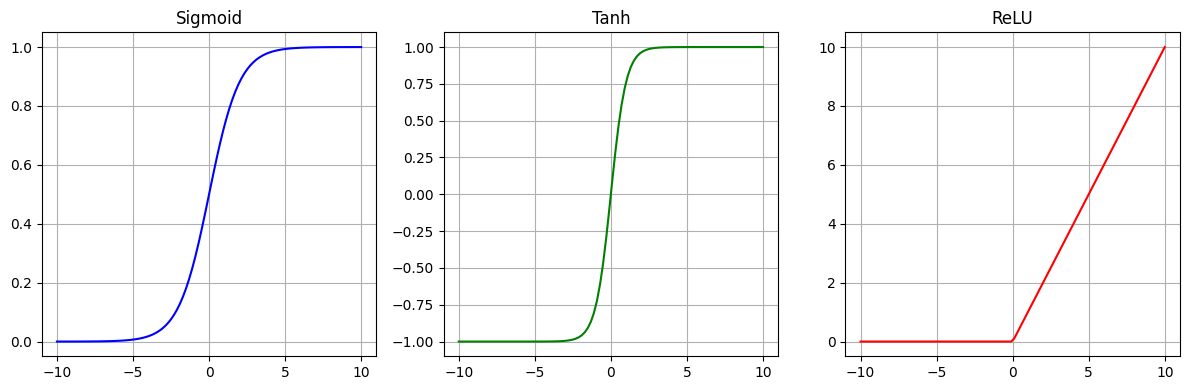

Dinesh Kumar P 24BAD019


In [6]:
x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(12, 4))

# Sigmoid Plot
plt.subplot(1, 3, 1)
plt.plot(x, sigmoid, label="Sigmoid", color='blue')
plt.title("Sigmoid")
plt.grid(True)

# Tanh Plot
plt.subplot(1, 3, 2)
plt.plot(x, tanh, label="Tanh", color='green')
plt.title("Tanh")
plt.grid(True)

# ReLU Plot
plt.subplot(1, 3, 3)
plt.plot(x, relu, label="ReLU", color='red')
plt.title("ReLU")
plt.grid(True)

plt.tight_layout()
plt.show()
print("Dinesh Kumar P 24BAD019")


Training with SIGMOID activation:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SIGMOID -> Final Train Acc: 0.9899 | Final Val Acc: 0.9771

Training with TANH activation:
TANH -> Final Train Acc: 0.9956 | Final Val Acc: 0.9744

Training with RELU activation:


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RELU -> Final Train Acc: 0.9932 | Final Val Acc: 0.9765


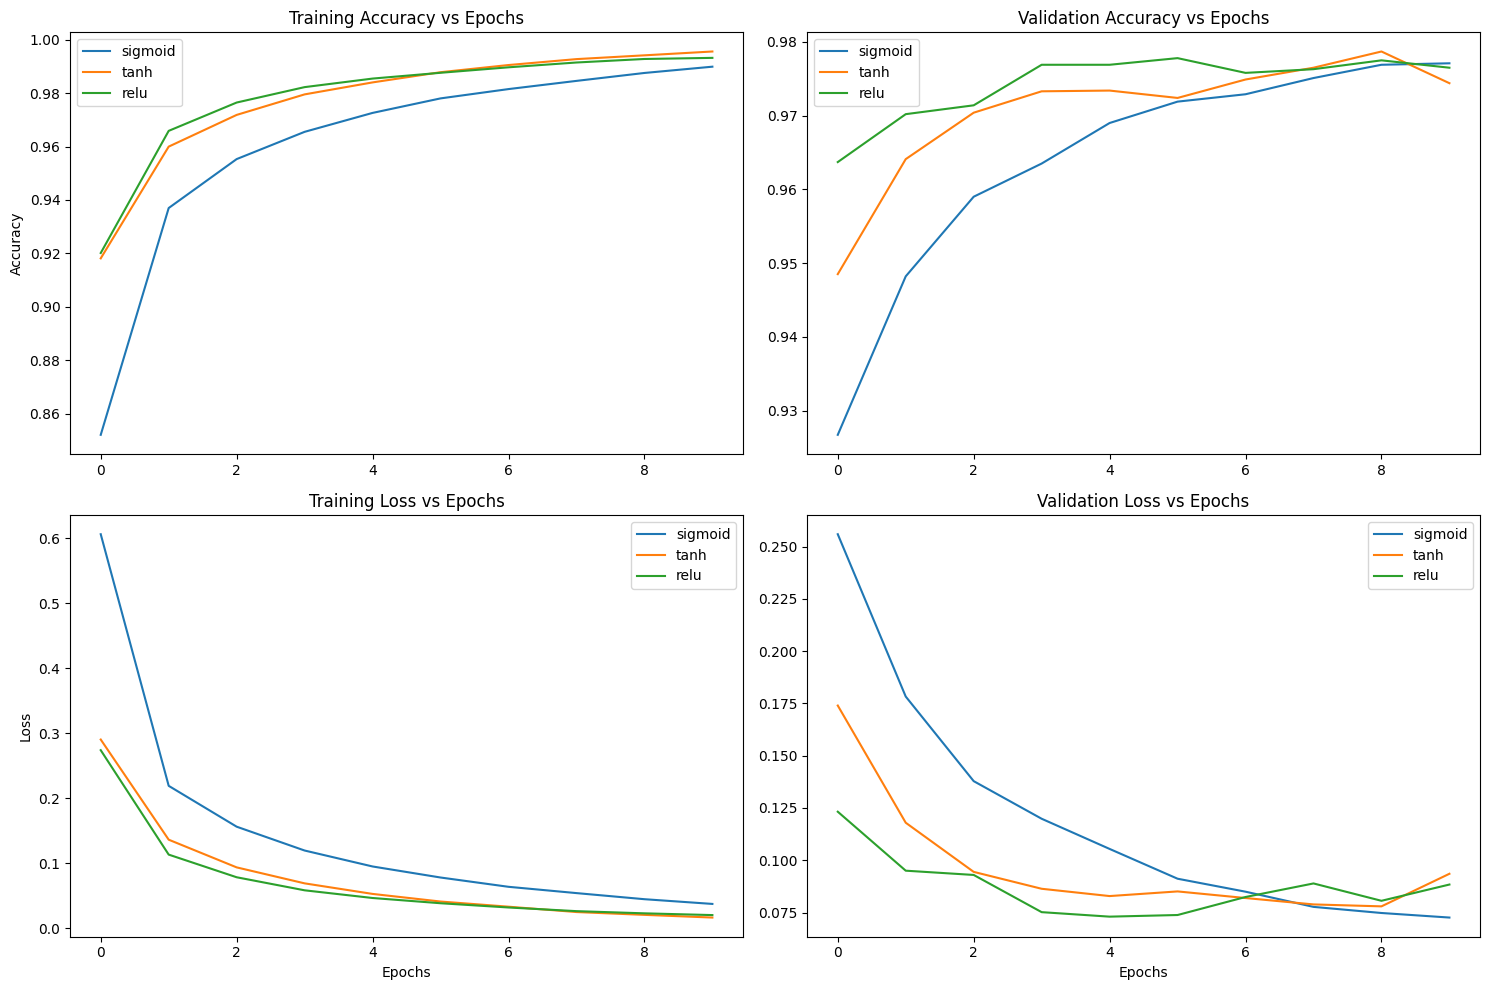

Dinesh Kumar P - 24BAD021


In [3]:
def build_model(activation_function):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

activations = ['sigmoid', 'tanh', 'relu']
history_dict_activations = {}

for act in activations:
    print(f"\nTraining with {act.upper()} activation:")
    model = build_model(act)
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64, verbose=0)
    history_dict_activations[act] = history.history

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{act.upper()} -> Final Train Acc: {final_train_acc:.4f} | Final Val Acc: {final_val_acc:.4f}")

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for act in activations:
    # Plot Training Accuracy
    axs[0, 0].plot(history_dict_activations[act]['accuracy'], label=act)
    axs[0, 0].set_title('Training Accuracy vs Epochs')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend()

    # Plot Validation Accuracy
    axs[0, 1].plot(history_dict_activations[act]['val_accuracy'], label=act)
    axs[0, 1].set_title('Validation Accuracy vs Epochs')
    axs[0, 1].legend()

    # Plot Training Loss
    axs[1, 0].plot(history_dict_activations[act]['loss'], label=act)
    axs[1, 0].set_title('Training Loss vs Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].legend()

    # Plot Validation Loss
    axs[1, 1].plot(history_dict_activations[act]['val_loss'], label=act)
    axs[1, 1].set_title('Validation Loss vs Epochs')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].legend()

plt.tight_layout()
plt.show()
print("Dinesh Kumar P - 24BAD021")


--- Training with SGD optimizer ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


SGD -> Final Train Acc: 0.9520 | Final Val Acc: 0.9527

--- Training with Momentum optimizer ---
Momentum -> Final Train Acc: 0.9910 | Final Val Acc: 0.9789

--- Training with RMSprop optimizer ---
RMSprop -> Final Train Acc: 0.9936 | Final Val Acc: 0.9787

--- Training with Adam optimizer ---
Adam -> Final Train Acc: 0.9942 | Final Val Acc: 0.9783


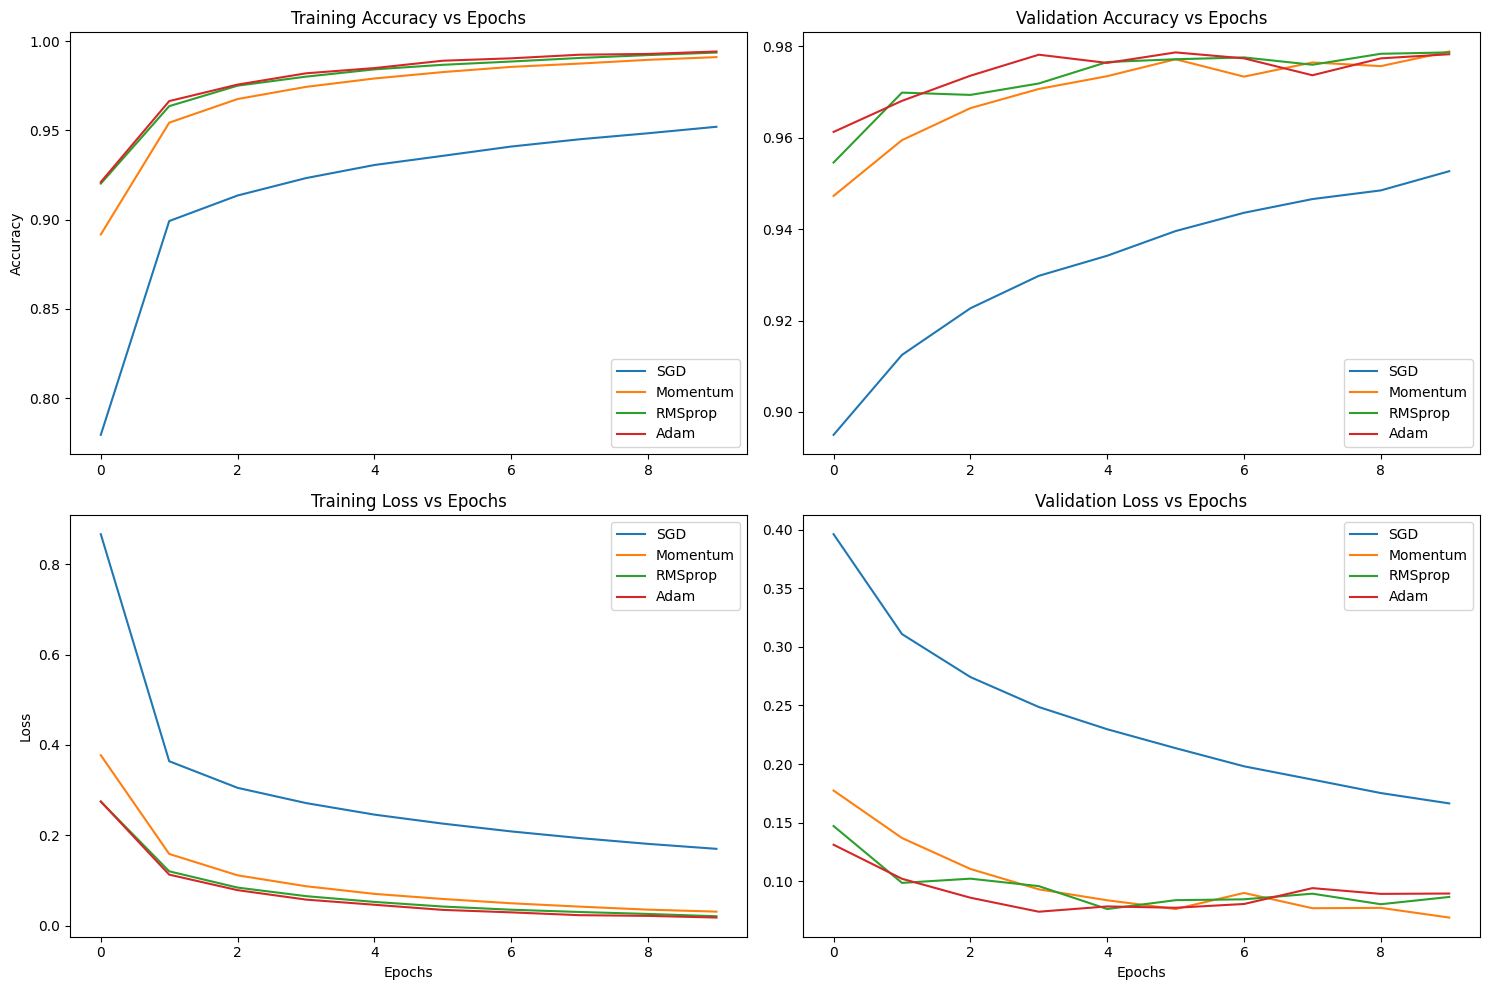

Dinesh Kumar P - 24BAD021


In [4]:
def build_model_opt():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

history_dict_opt = {}

for opt_name, opt in optimizers.items():
    print(f"\n--- Training with {opt_name} optimizer ---")
    model = build_model_opt()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64, verbose=0)
    history_dict_opt[opt_name] = history.history

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{opt_name} -> Final Train Acc: {final_train_acc:.4f} | Final Val Acc: {final_val_acc:.4f}")

# Visualizing Optimizer Performance
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for opt_name in optimizers.keys():
    # Training Accuracy
    axs[0, 0].plot(history_dict_opt[opt_name]['accuracy'], label=opt_name)
    axs[0, 0].set_title('Training Accuracy vs Epochs')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend()

    # Validation Accuracy
    axs[0, 1].plot(history_dict_opt[opt_name]['val_accuracy'], label=opt_name)
    axs[0, 1].set_title('Validation Accuracy vs Epochs')
    axs[0, 1].legend()

    # Training Loss
    axs[1, 0].plot(history_dict_opt[opt_name]['loss'], label=opt_name)
    axs[1, 0].set_title('Training Loss vs Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].legend()

    # Validation Loss
    axs[1, 1].plot(history_dict_opt[opt_name]['val_loss'], label=opt_name)
    axs[1, 1].set_title('Validation Loss vs Epochs')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].legend()

plt.tight_layout()
plt.show()
print("Dinesh Kumar P - 24BAD021")

In [7]:
import os

save_path = '/kaggle/working/DL_Experiments'
os.makedirs(save_path, exist_ok=True)

model.save(f'{save_path}/best_mnist_model.keras')
print(f"\nModel successfully saved to Kaggle working directory: {save_path}/best_mnist_model.keras")
print("Dinesh Kumar P 24BAD019")


Model successfully saved to Kaggle working directory: /kaggle/working/DL_Experiments/best_mnist_model.keras
Dinesh Kumar P 24BAD019
